In [90]:
#Import required libraries
import pandas as pd 
import numpy as np
from datetime import datetime
from pyscipopt import Model, quicksum
import warnings
warnings.filterwarnings("ignore")
%pylab inline
import yfinance as yf
from pyscipopt import Model as SCIPModel, quicksum

import nsepython as nse
from jugaad_data.nse import bhavcopy_save, bhavcopy_fo_save
from jugaad_data.nse import stock_df, index_df


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [38]:
# bhavcopy_fo_save(datetime.date(2025,1,1), r"C:\Users\akhil\IITB\S3\fo")

In [ ]:

# Download bhavcopy
bhavcopy_save(date(2020,1,1), "/path/to/directory")

# Download bhavcopy for futures and options
bhavcopy_fo_save(date(2020,1,1), "/path/to/directory")

# Download stock data to pandas dataframe
df = stock_df(symbol="SBIN", from_date=date(2020,1,1),
            to_date=date(2020,1,30), series="EQ")

## SET TIME PER ITERATION

In [124]:
#10 s for testing code
time = 3600

In [3]:
nse_tickers = {
    'HINDALCO.NS': 'Hindalco Industries',
    'TATASTEEL.NS': 'Tata Steel',
    'JSWSTEEL.NS': 'JSW Steel',
    'COALINDIA.NS': 'Coal India',
    'ONGC.NS': 'Oil & Natural Gas Corp',
    # 'JIOFIN.NS': 'Jio Financial Services',
    'TRENT.NS': 'Trent Ltd',
    'GRASIM.NS': 'Grasim Industries',
    'CIPLA.NS': 'Cipla Ltd',
    'POWERGRID.NS': 'Power Grid Corp',
    'ADANIENT.NS': 'Adani Enterprises',
    'KOTAKBANK.NS': 'Kotak Mahindra Bank',
    'SBILIFE.NS': 'SBI Life Insurance',
    'NTPC.NS': 'NTPC Ltd',
    'BAJAJFINSV.NS': 'Bajaj Finserv',
    'RELIANCE.NS': 'Reliance Industries',
    'HDFCBANK.NS': 'HDFC Bank',
    'BHARTIARTL.NS': 'Bharti Airtel',
    'DRREDDY.NS': "Dr Reddy's Labs",
    'SUNPHARMA.NS': 'Sun Pharma',
    'BAJFINANCE.NS': 'Bajaj Finance',
    'ADANIPORTS.NS': 'Adani Ports',
    'SHRIRAMFIN.NS': 'Shriram Finance',
    'BAJAJ-AUTO.NS': 'Bajaj Auto',
    'EICHERMOT.NS': 'Eicher Motors',
    'TATAMOTORS.NS': 'Tata Motors',
    'M&M.NS': 'Mahindra & Mahindra',
    'HEROMOTOCO.NS': 'Hero MotoCorp',
    'TITAN.NS': 'Titan Company',
    'LT.NS': 'Larsen & Toubro',
    'SBIN.NS': 'State Bank of India',
    'BEL.NS': 'Bharat Electronics',
    'ICICIBANK.NS': 'ICICI Bank',
    'MARUTI.NS': 'Maruti Suzuki',
    'WIPRO.NS': 'Wipro',
    'ITC.NS': 'ITC Ltd',
    'ULTRACEMCO.NS': 'UltraTech Cement',
    'HCLTECH.NS': 'HCL Technologies',
    'TATACONSUM.NS': 'Tata Consumer',
    'AXISBANK.NS': 'Axis Bank',
    'TECHM.NS': 'Tech Mahindra',
    'NESTLEIND.NS': 'Nestle India',
    'HINDUNILVR.NS': 'Hindustan Unilever',
    'INDUSINDBK.NS': 'IndusInd Bank',
    'HDFCLIFE.NS': 'HDFC Life',
    'INFY.NS': 'Infosys',
    'APOLLOHOSP.NS': 'Apollo Hospitals',
    'ASIANPAINT.NS': 'Asian Paints',
    'TCS.NS': 'Tata Consultancy Services'
}

In [31]:
  # or nsepythonserver

# df_hist = equity_history(
#     symbol="RELIANCE",
#     series="EQ",
#     start_date="01-05-2022",
#     end_date="31-08-2025"
# )
# print(df_hist.head())

In [67]:
# df.head(1)

In [26]:
# !pip install jugaad_data

In [39]:
# from jugaad_data.nse import stock_df
# df = stock_df(symbol="SBIN", from_date=datetime.date(2020,1,1),
#             to_date=datetime.date(2020,1,30), series="FNO")

In [72]:
df1 = pd.DataFrame()
ticks = []
for stock in list(nse_tickers.keys()):
    ticker = stock.split('.')[0]
    df = stock_df(symbol="SBIN", from_date= datetime.date(2023,5,1),
            to_date=datetime.date(2025,8,30), series="EQ")[['DATE','CLOSE']]
    df = df.set_index('DATE')
    df = df.rename(columns = {'CLOSE' :ticker})
    df1 = pd.concat([df1, df], axis = 1)
    ticks.append(ticker)
    

In [68]:
# derivatives_df(symbol, from_date, to_date, expiry_date, instrument_type, strike_price=None, option_type=None)

In [94]:
# index_df('NIFTY', from_date= datetime.date(2023,5,1), to_date=datetime.date(2025,8,30))

In [95]:
# import inspect
# print(inspect.getsource(index_df))

In [69]:
# nifty_index = '^NSEI'

# tickers = [nifty_index] + list(nse_tickers.keys())

# Download close prices
# data1 = yf.download(tickers, start="2022-05-01", end="2025-08-31")['Close']

# data.to_csv('nifty50_close_prices.csv')


In [101]:
a1.columns

Index(['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (₹ Cr)'],
      dtype='object')

In [104]:
path = r'C:\Users\akhil\IITB\S3'
a1 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-01-01-2023-to-30-08-2023.csv')[['Date ','Close ']]
a2 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-30-08-2023-to-30-08-2024.csv')[['Date ','Close ']]
a3 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-30-08-2024-to-30-08-2025.csv')[['Date ','Close ']]

nifty1 = pd.concat([a1,a2,a3], axis = 0)
nifty1 = nifty1.rename(columns = {"Date ": 'Date', "Close ":'NIFTY50'})
nifty1['Date'] = pd.to_datetime(nifty1['Date'])
nifty2 = nifty1.set_index("Date")
nifty = nifty2.sort_index()

In [114]:
#Cleaning Data
df1 = df1.sort_index()[ticks]
merged = df1.merge(nifty, left_index=True, right_index=True, how="left")
data = merged.ffill()

In [6]:
# df_2020 = data.loc[data.index[(data.index >= pd.to_datetime('2020-01-01')) & (data.index < pd.to_datetime('2024-01-01'))]]
# df_2021 = data.loc[data.index[(data.index >= pd.to_datetime('2021-01-01')) & (data.index < pd.to_datetime('2022-01-01'))]]
# df_2022 = data.loc[data.index[(data.index >= pd.to_datetime('2022-01-01')) & (data.index < pd.to_datetime('2023-01-01'))]]
# df_2023 = data.loc[data.index[(data.index >= pd.to_datetime('2023-01-01')) & (data.index < pd.to_datetime('2024-01-01'))]]
# df_2024 = data.loc[data.index[(data.index >= pd.to_datetime('2024-01-01')) & (data.index < pd.to_datetime('2025-01-01'))]]
# df_2025 = data.loc[data.index[(data.index >= pd.to_datetime('2025-01-01')) & (data.index < pd.to_datetime('2026-01-01'))]]


### Setting up the Optimization

In [120]:
num_stocks = len(data.columns) - 1

# creating array for m values 
m_values = [len(ticks)]
m = [x for x in m_values if x <= num_stocks]

In [132]:
# data_returns

In [122]:
#creating a dataframe containing daily returns of stocks 
data_returns = data/data.shift(1) - 1

#calculating correlation between different stocks and creating the matrix
df_corr = data.corr().iloc[1:,1:]

### Formulation of the Optimization
- $ w_i \in [0, 1] $: weight of stock $ i $
- $ y_i \in \{0, 1\} $: binary indicator, 1 if stock $ i $ is selected  
- $ e_t \geq 0 $: tracking error at time $ t $  
- $ r_{t,i} $: return of stock $ i $ at time $ t $  
- $ q_t $: index return at time $ t $  
- $ n $: number of stocks  
- $ N $: number of time periods  
- $ m $: number of stocks to be selected  

---

## ***Objective:***
$$
\min \sum_{t=1}^{N} e_t
$$
---

**Subject to:**

1. **Cardinality Constraint (select exactly \( m \) stocks):**

$$
\sum_{i=1}^{n} y_i = m
$$

2. **Weight only if selected:**

$$
w_i \leq y_i \quad \forall i = 1,\dots,n
$$

3. **Budget Constraint (weights sum to 1):**

$$
\sum_{i=1}^{n} w_i = 1
$$

4. **Tracking Error Constraints:**

$$
\sum_{i=1}^{n} r_{t,i} \cdot w_i - e_t \leq q_t \quad \forall t = 1,\dots,N
$$
$$
\sum_{i=1}^{n} r_{t,i} \cdot w_i + e_t \geq q_t \quad \forall t = 1,\dots,N
$$

---

**Variable Domains:**

$$
\begin{aligned}
w_i &\in [0, 1] \quad \forall i \\
y_i &\in \{0, 1\} \quad \forall i \\
e_t &\geq 0 \quad \forall t
\end{aligned}
$$


In [133]:
objvalues = []
stock_selection = {}
weights = {}

N = len(data) - 1  # number of time periods
n = len(df_corr)      # number of stocks

q = data[['NIFTY50']].reset_index(drop=True)
# q = data_returns[['NIFTY50']].reset_index(drop=True)

r = data.drop(columns=['NIFTY50']).reset_index(drop=True)
# r = data_returns.drop(columns=['NIFTY50']).reset_index(drop=True)


for mval in m:
    model = SCIPModel(f"MinTrackingError_m={mval}")
    
    # Variables
    e = {t: model.addVar(name=f"e_{t}") for t in range(N)}                  # error vars
    w = {i: model.addVar(lb=0.0, ub=1.0, name=f"w_{i}") for i in range(n)}  # weight vars
    y = {i: model.addVar(vtype='BINARY', name=f"y_{i}") for i in range(n)}  # selection binary vars

    # Objective: minimize sum of e[t]
    model.setObjective(quicksum(e[t] for t in range(N)), "minimize")

    # Constraint 1: number of selected stocks = mval
    model.addCons(quicksum(y[i] for i in range(n)) == mval)

    # Constraint 2: w[i] ≤ y[i]
    for i in range(n):
        model.addCons(w[i] <= y[i])

    # Constraint 3: sum of weights = 1
    model.addCons(quicksum(w[i] for i in range(n)) == 1)

    # Constraint 4: tracking error bounds
    for t in range(1, N+1):  # skip first row 
        rhs = float(q.iloc[t])
        coeffs = r.iloc[t].values
        model.addCons(quicksum(coeffs[i] * w[i] for i in range(n)) - e[t-1] <= rhs)
        model.addCons(quicksum(coeffs[i] * w[i] for i in range(n)) + e[t-1] >= rhs)

    # Set solver time limit to time Seconds (defined at the begining of the code)
    model.setRealParam("limits/time", time)

    # Suppress solver output
    model.hideOutput()
    
    # Solve the problem
    model.optimize()

    # Check for best solution
    best_solution = model.getBestSol()

    # If no solution was found, skip
    if best_solution is None:
        print(f"No feasible solution found for m = {mval}")
        objvalues.append(None)
        continue

    # Save objective value
    objvalues.append(model.getSolObjVal(best_solution))

    # Extract variable values
    var_vals = [model.getSolVal(best_solution, e[t]) for t in range(N)] + \
               [model.getSolVal(best_solution, w[i]) for i in range(n)] + \
               [model.getSolVal(best_solution, y[i]) for i in range(n)]

    pd.DataFrame(var_vals).to_excel(f"obj_values_{mval}.xlsx")
    stock_selection[mval] = [model.getSolVal(best_solution, y[i]) for i in range(n)]
    weights[mval] = [model.getSolVal(best_solution, w[i]) for i in range(n)]


### Comparison of Performance

In [10]:
# calculating returns matrix 
df_2024_returns = df_2024/df_2024.shift(1) - 1 
df_2025_returns = df_2025/df_2025.shift(1) - 1 

In [11]:
def calculate_tracking_error(returns, weights, benchmark):
    portfolio = returns.dot(weights)
    tracking_error = np.sqrt(np.mean((portfolio - benchmark)**2))
    return tracking_error

tracking_errors_2024 = {}
tracking_errors_2025 = {}

for mval in m:
    w = np.array(weights[mval])
    selected_cols = df_corr.index[np.array(stock_selection[mval]) == 1]

    returns_2024 = df_2024_returns[selected_cols]
    returns_2025 = df_2025_returns[selected_cols]

    tracking_errors_2024[mval] = calculate_tracking_error(returns_2024, w[np.array(stock_selection[mval]) == 1], df_2024_returns.iloc[:, 0])
    tracking_errors_2025[mval] = calculate_tracking_error(returns_2025, w[np.array(stock_selection[mval]) == 1], df_2025_returns.iloc[:, 0])


In [12]:
def cumulative_returns(returns, weights):
    return (1 + returns.dot(weights)).cumprod()

cumulative_2024 = {}
cumulative_2025 = {}

for mval in m:
    w = np.array(weights[mval])
    selected_cols = df_corr.index[np.array(stock_selection[mval]) == 1]

    cumulative_2024[mval] = cumulative_returns(df_2024_returns[selected_cols], w[np.array(stock_selection[mval]) == 1])
    cumulative_2025[mval] = cumulative_returns(df_2025_returns[selected_cols], w[np.array(stock_selection[mval]) == 1])


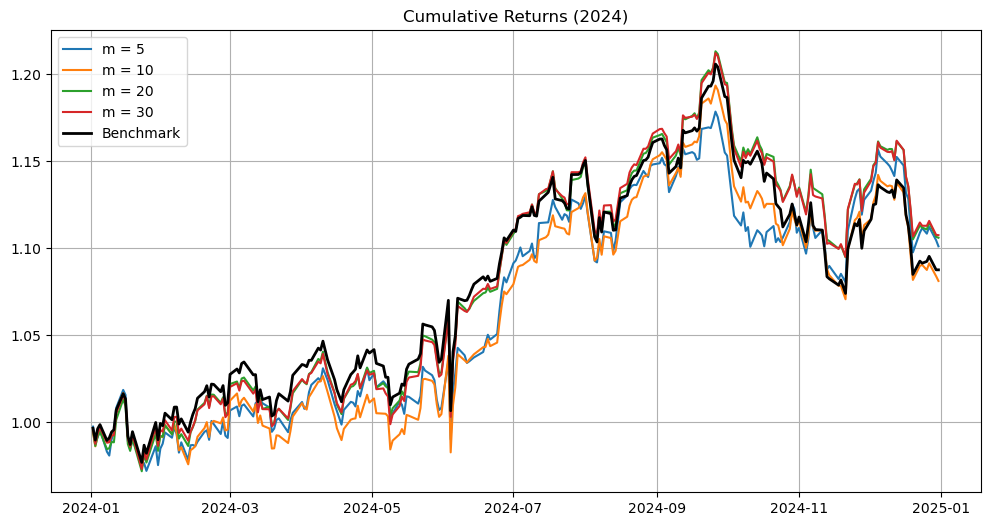

In [13]:
plt.figure(figsize=(12,6))
for mval in m:
    plt.plot(cumulative_2024[mval], label=f'm = {mval}')
plt.plot((1 + df_2024_returns.iloc[:, 0]).cumprod(), label='Benchmark', linewidth=2, color='black')
plt.legend()
plt.title("Cumulative Returns (2024)")
plt.grid(True)
plt.show()

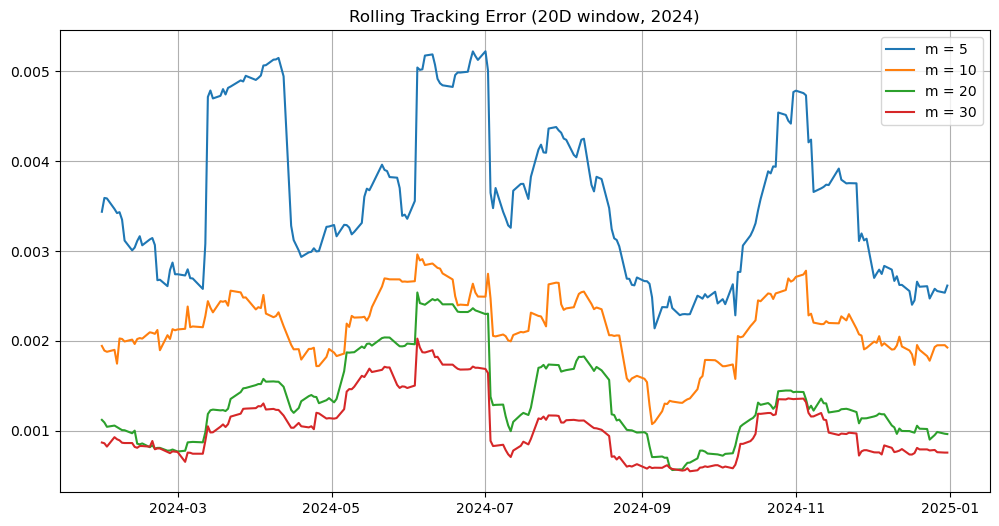

In [14]:
rolling_te = {}
window = 20

for mval in m:
    w = np.array(weights[mval])
    selected_cols = df_corr.index[np.array(stock_selection[mval]) == 1]
    p_returns = df_2024_returns[selected_cols].dot(w[np.array(stock_selection[mval]) == 1])
    b_returns = df_2024_returns.iloc[:, 0]
    rolling_te[mval] = (p_returns - b_returns).rolling(window).std()

# Plot
plt.figure(figsize=(12,6))
for mval in m:
    plt.plot(rolling_te[mval], label=f"m = {mval}")
plt.title("Rolling Tracking Error (20D window, 2024)")
plt.legend()
plt.grid(True)
plt.show()

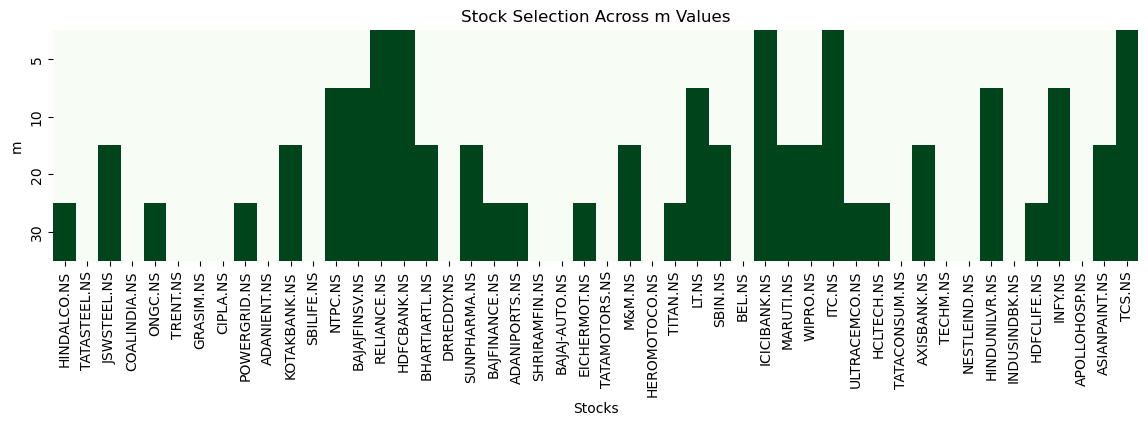

In [15]:
import seaborn as sns
stats_list = []

for mval in m:
    w = np.array(weights[mval])
    selected_cols = df_corr.index[np.array(stock_selection[mval]) == 1]
    p2024 = df_2024_returns[selected_cols].dot(w[np.array(stock_selection[mval]) == 1])
    p2025 = df_2025_returns[selected_cols].dot(w[np.array(stock_selection[mval]) == 1])

    stats_list.append({
        "m": mval,
        "TE_2024": tracking_errors_2024[mval],
        "TE_2025": tracking_errors_2025[mval],
        "Mean_2024": p2024.mean(),
        "Vol_2024": p2024.std(),
        "Mean_2025": p2025.mean(),
        "Vol_2025": p2025.std(),
    })

stats_df = pd.DataFrame(stats_list)

selection_df = pd.DataFrame(stock_selection, index=df_corr.index).T

plt.figure(figsize=(14,3))
sns.heatmap(selection_df, cmap="Greens", cbar=False)
plt.title("Stock Selection Across m Values")
plt.xlabel("Stocks")
plt.ylabel("m")
plt.show()

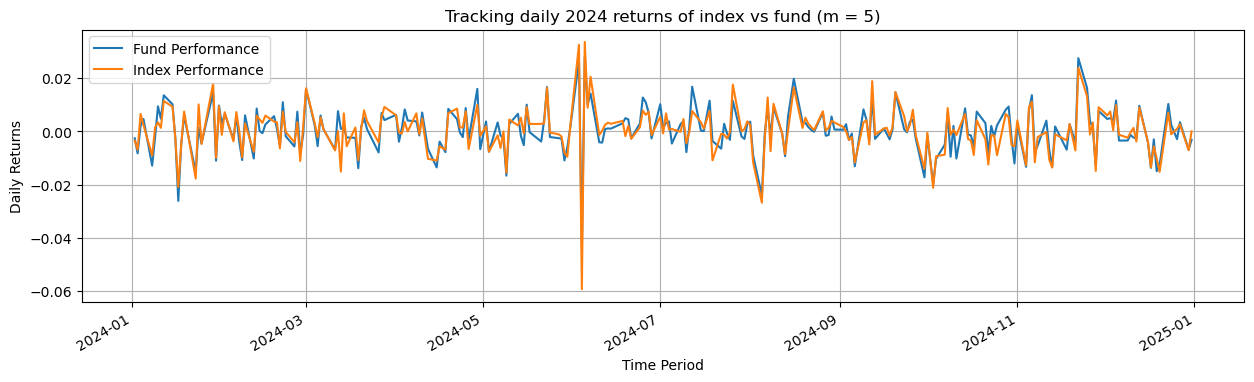

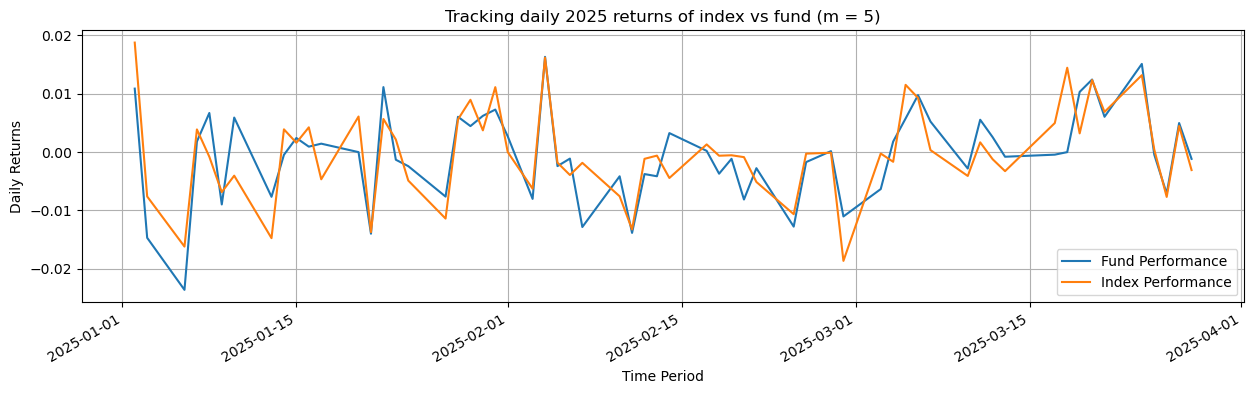

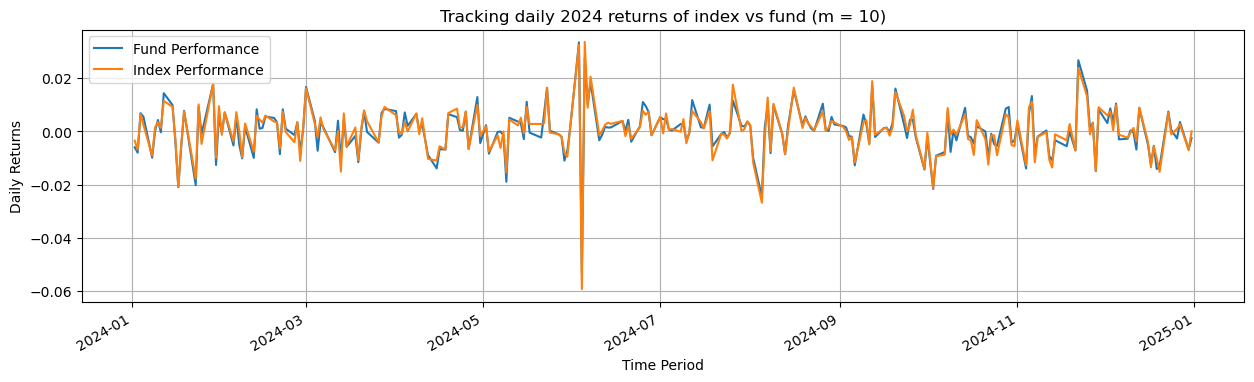

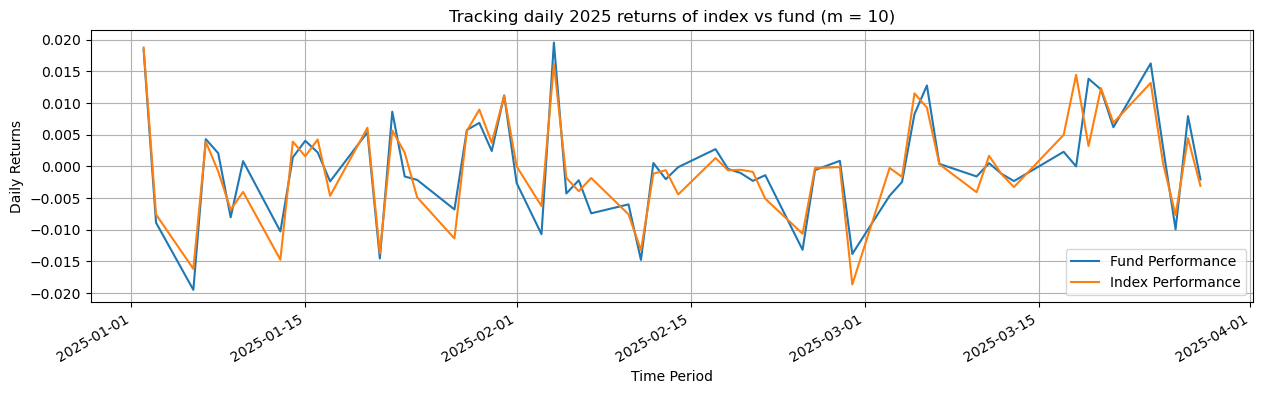

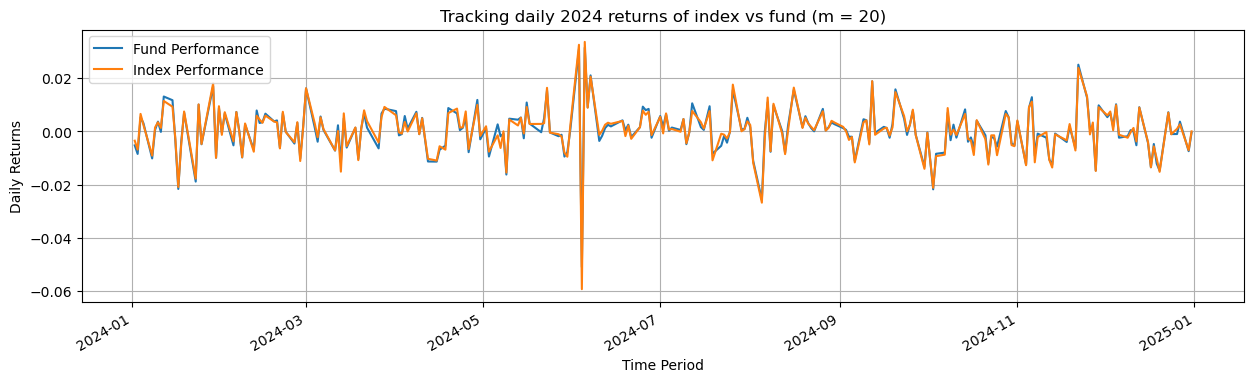

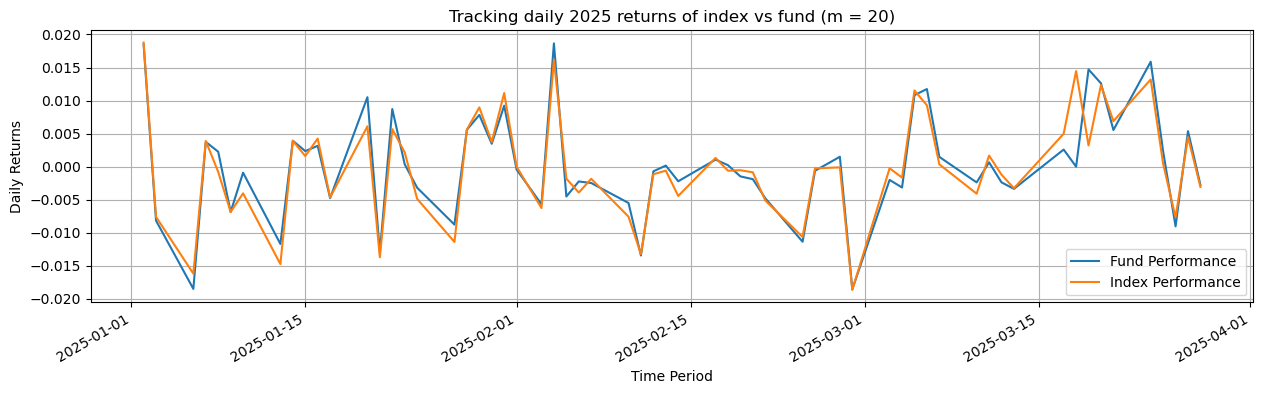

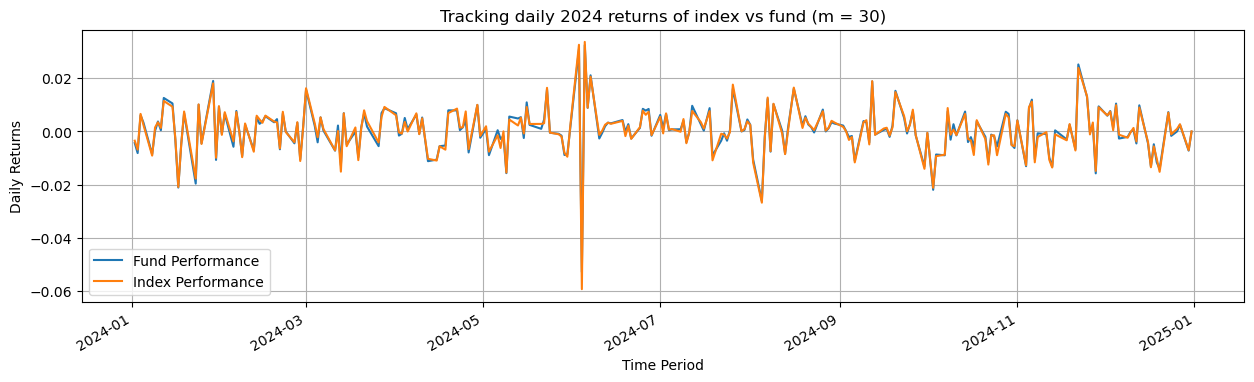

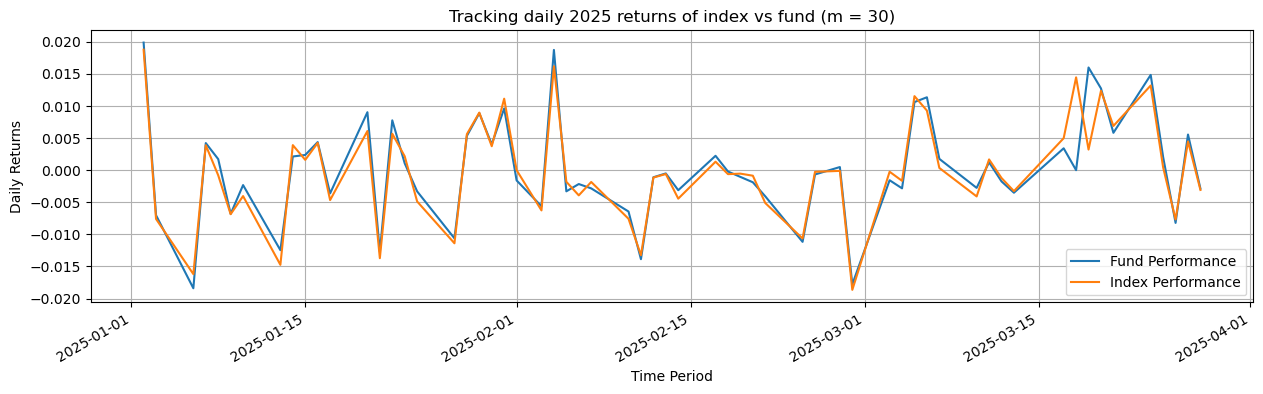

In [16]:
import matplotlib.pyplot as plt

for mval in m:
    if mval not in stock_selection:
        continue  # skip if no solution found for this m

    selected_indices = np.array(stock_selection[mval]) == 1
    selected_stocks = df_corr.index[selected_indices]
    selected_weights = np.array(weights[mval])[selected_indices]

    # Check if selected_stocks is empty
    if len(selected_stocks) == 0:
        print(f"No stocks selected for m = {mval}")
        continue

    # Compute portfolio returns
    portfolio_2024 = df_2024_returns[selected_stocks].dot(selected_weights)
    portfolio_2025 = df_2025_returns[selected_stocks].dot(selected_weights)

    # Index returns
    index_2024 = df_2024_returns['^NSEI']
    index_2025 = df_2025_returns['^NSEI']

    # Plot for 2024
    plt.figure(figsize=(15, 4))
    portfolio_2024.plot(label='Fund Performance')
    index_2024.plot(label='Index Performance')
    plt.legend()
    plt.xlabel('Time Period')
    plt.ylabel('Daily Returns')
    plt.title(f'Tracking daily 2024 returns of index vs fund (m = {mval})')
    plt.grid(True)
    plt.show()

    # Plot for 2025
    plt.figure(figsize=(15, 4))
    portfolio_2025.plot(label='Fund Performance')
    index_2025.plot(label='Index Performance')
    plt.legend()
    plt.xlabel('Time Period')
    plt.ylabel('Daily Returns')
    plt.title(f'Tracking daily 2025 returns of index vs fund (m = {mval})')
    plt.grid(True)
    plt.show()


In [17]:
df_performance_mip = pd.DataFrame(columns=['2020', '2024', '2025'], index=m)

for mval in m:
    selected_indices = np.array(stock_selection[mval]) == 1
    selected_weights = np.array(weights[mval])[selected_indices]
    selected_stocks = df_corr.index[selected_indices]

    # Fund vs Index daily returns
    fund_2020 = df_2020_returns[selected_stocks].dot(selected_weights)
    fund_2024 = df_2024_returns[selected_stocks].dot(selected_weights)
    fund_2025 = df_2025_returns[selected_stocks].dot(selected_weights)

    # Tracking error (sum of absolute daily return differences)
    tracking_error_2020 = np.abs(df_2020_returns['^NSEI'] - fund_2020).sum()
    tracking_error_2024 = np.abs(df_2024_returns['^NSEI'] - fund_2024).sum()
    tracking_error_2025 = np.abs(df_2025_returns['^NSEI'] - fund_2025).sum()

    # Store in DataFrame
    df_performance_mip.loc[mval, '2020'] = tracking_error_2020
    df_performance_mip.loc[mval, '2024'] = tracking_error_2024
    df_performance_mip.loc[mval, '2025'] = tracking_error_2025


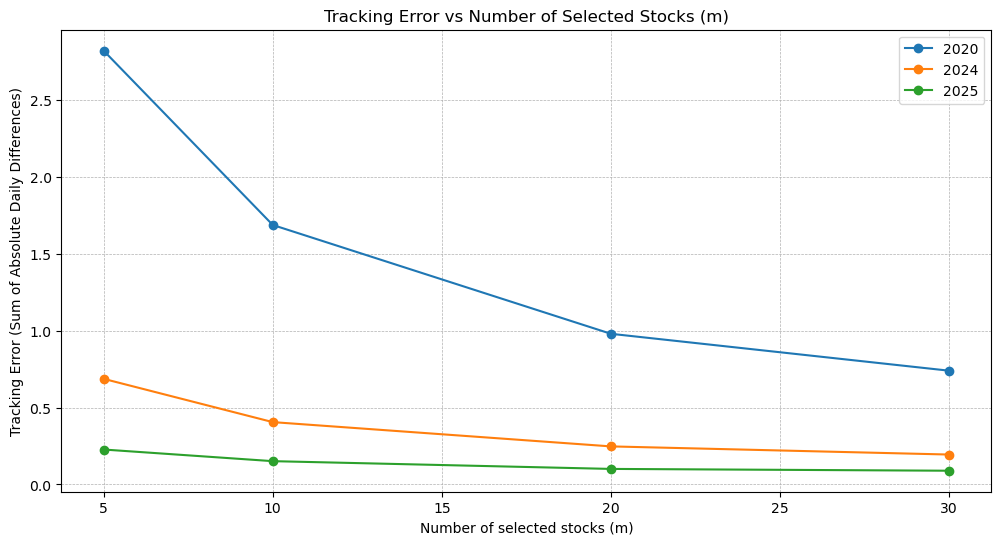

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
df_performance_mip.astype(float).plot(ax=ax, marker='o')
ax.set_title('Tracking Error vs Number of Selected Stocks (m)')
ax.set_xlabel('Number of selected stocks (m)')
ax.set_ylabel('Tracking Error (Sum of Absolute Daily Differences)')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()
